In [2]:
import numpy as np
import matplotlib.pyplot as plt
import hcipy as hci

### pupil/ telescope params :
- telescope diam. 
- central obscuration : the diam. of the block in the middle of the pupil
- central obscuration ratio
- spider width : the arms/handles that hold the obscuration in place 
- oversizing factor : 

In [ ]:
# physical measurements
telescope_diameter = 8.0       # [m]
central_obscuration = 1.2      # [m]
central_obscuration_ratio = central_obscuration / telescope_diameter
spider_width = 0.05            # [m]
# simulation auxillary
oversizing_factor = 16.0 / 15.0
num_pupil_pixels_base = 240
num_pupil_pixels = int(num_pupil_pixels_base * oversizing_factor)  # must be int
pupil_grid_diameter = telescope_diameter * oversizing_factor
pupil_grid = hci.make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)

using the specifications to create the pupil generator :

In [38]:
VLT_aperture_generator = hci.make_obstructed_circular_aperture(
    telescope_diameter,
    central_obscuration_ratio,
    num_spiders=4,
    spider_width=spider_width
)

creating an instance of a pupil :

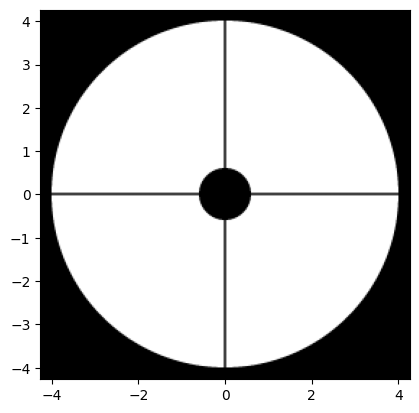

In [39]:
VLT_aperture = hci.evaluate_supersampled(VLT_aperture_generator, pupil_grid, 4)
hci.imshow_field(VLT_aperture,cmap="gray")

setting reference wavelengths of wavefronts for basic simulation :

In [11]:
wavelength_wfs = 0.7e-6   # [m] (not used below, kept for context)
wavelength_sci = 2.2e-6   # [m]

creating the normalized wavefront object which we propagte througe the pupil :

In [63]:
wf = hci.Wavefront(VLT_aperture.copy(), wavelength_sci)
wf.total_power = 1.0  # normalize total power at pupil plane

creating a grid that represents the plane in which the propagation of the wavefront is sampled in discrete pixels :

In [64]:
spatial_resolution = wavelength_sci / telescope_diameter
focal_grid = hci.make_focal_grid(q=4, num_airy=30, spatial_resolution=spatial_resolution)

the propagator object is constructed from the pupil object and the focal grid object, this allows the propagtor to match the output grid to the ratios previously specified.

In [68]:
propagator = hci.FraunhoferPropagator(pupil_grid, focal_grid)

after the wave is passed through the propagator and the output is a field represented as a complex grid, the intensity and power spectrum of the field is calculated :

In [69]:
E_img = propagator.forward(wf)          # complex field
I_img = E_img.power                     # intensity Field on focal_grid (PSF)

we shape the intensity np.array as a matrix representing the grid and make sure it makes sense :

In [70]:
I2 = I_img.shaped
ny, nx = focal_grid.shape
assert ny >= 3 and nx >= 3, "Focal grid must be at least 3x3 for a 3x3 bucket."

choosing the pixels that represent the fiber within the pupil.
in these pixels we sum the matching intensity values to get the overall intensity recieved in the channel :

In [27]:
cy, cx = ny // 2, nx // 2
rows = slice(cy - 1, cy + 2)
cols = slice(cx - 1, cx + 2)
mask2 = np.zeros_like(I2, dtype=float)
mask2[rows, cols] = 1.0
bucket_mask = hci.Field(mask2.ravel(), focal_grid)

plot output together :

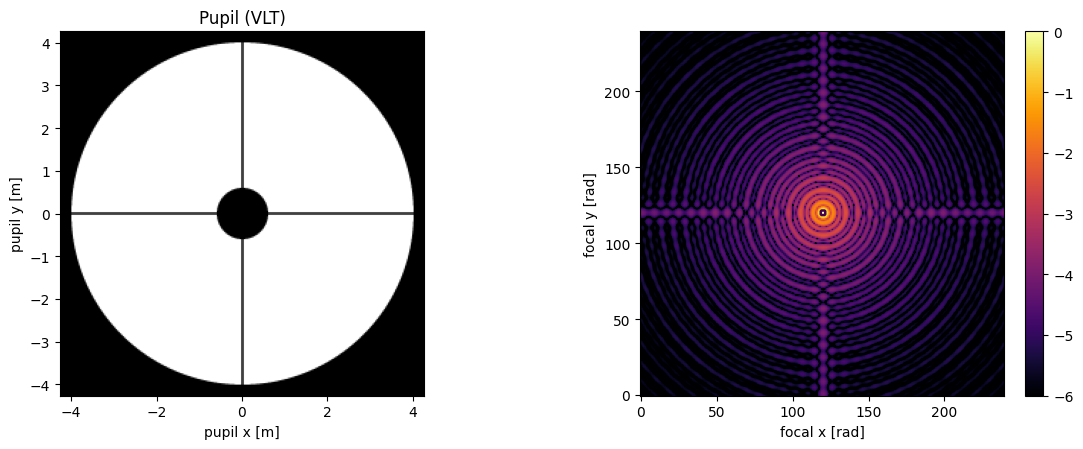

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# Left: pupil
hci.imshow_field(VLT_aperture, cmap='gray', ax=axes[0])
axes[0].set_title('Pupil (VLT)')
axes[0].set_xlabel('pupil x [m]')
axes[0].set_ylabel('pupil y [m]')

# Right: PSF (log10) + 3×3 bucket outline
im1 = axes[1].imshow(np.log10(I2 / I2.max()), origin='lower',cmap='inferno', vmin=-6)
# Overlay the 3×3 boundary as a contour
axes[1].contour(mask2, levels=[0.5], linewidths=1.8)
axes[1].set_xlabel('focal x [rad]')
axes[1].set_ylabel('focal y [rad]')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

plt.show()


In [71]:
I_img = E_img.power              # intensity on focal_grid (PSF), same as |E|^2
I2 = I_img.shaped

ny, nx = focal_grid.shape

assert ny >= 3 and nx >= 3

cy, cx = ny // 2, nx // 2
rows = slice(cy - 1, cy + 2)
cols = slice(cx - 1, cx + 2)

w = focal_grid.weights

In [ ]:
mask2 = np.zeros_like(I2, dtype=float)
mask2[rows, cols] = 1.0
bucket_mask = hci.Field(mask2.ravel(), focal_grid)

9.0


plot ouput of power spectrum

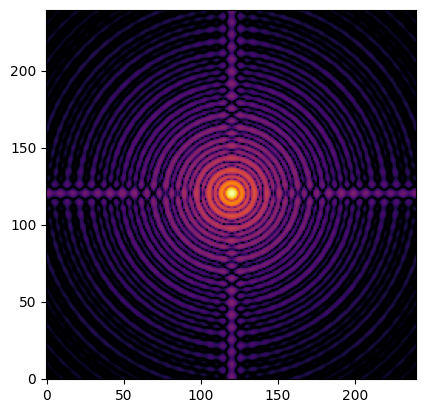

In [ ]:
plt.imshow(np.log10(I2 / I2.max()), origin='lower', cmap='inferno', vmin=-6)